In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob

# =========================
# LOAD DATA
# =========================
price_files = sorted(glob.glob("../../../data_capsule/ROUND_3/prices_round_3_day_*.csv"))
prices = pd.concat([pd.read_csv(f, sep=';') for f in price_files], ignore_index=True)


In [2]:
# Split
underlying = prices[prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
options = prices[prices["product"].str.contains("VEV_")].copy()

# Strike
options["strike"] = options["product"].str.split("_").str[1].astype(int)

# Mid prices
for d in [underlying, options]:
    d["mid"] = (d["bid_price_1"] + d["ask_price_1"]) / 2

# Merge underlying
df = options.merge(
    underlying[["day", "timestamp", "mid"]],
    on=["day", "timestamp"],
    suffixes=("", "_underlying")
)

df.rename(columns={"mid": "option_mid", "mid_underlying": "S"}, inplace=True)

# Time to expiry
df["T"] = 1 - df["timestamp"] / df["timestamp"].max()

# Sort
df = df.sort_values(["day", "timestamp", "strike"])


In [3]:

# =========================
# SPEED OPTIMIZATION
# =========================
df = df[(df["option_mid"] > 0) & (df["S"] > 0) & (df["T"] > 0)]
df = df[df["timestamp"] % 20 == 0]   # downsample

# =========================
# BS FUNCTIONS
# =========================
def implied_vol_newton(price, S, K, T, tol=1e-4, max_iter=20):
    sigma = 0.3
    
    for _ in range(max_iter):
        d1 = (np.log(S/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        
        price_est = S * norm.cdf(d1) - K * norm.cdf(d2)
        vega = S * norm.pdf(d1) * np.sqrt(T)
        
        if vega < 1e-8:
            return np.nan
        
        diff = price_est - price
        if abs(diff) < tol:
            return sigma
        
        sigma -= diff / vega
        
        if sigma <= 0: sigma = 1e-3
        if sigma > 5: sigma = 5
    
    return np.nan

# =========================
# IMPLIED VOL (FAST)
# =========================
df["iv"] = [
    implied_vol_newton(p, S, K, T)
    for p, S, K, T in zip(
        df["option_mid"].values,
        df["S"].values,
        df["strike"].values,
        df["T"].values
    )
]

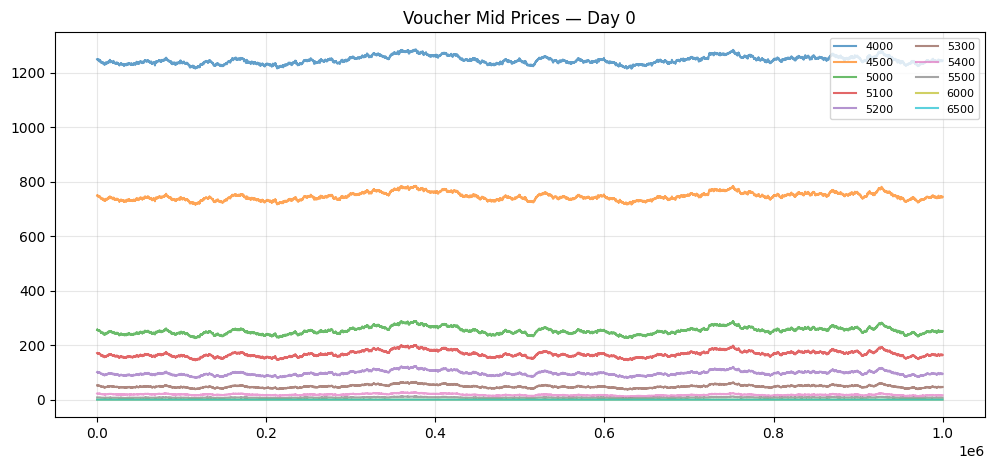

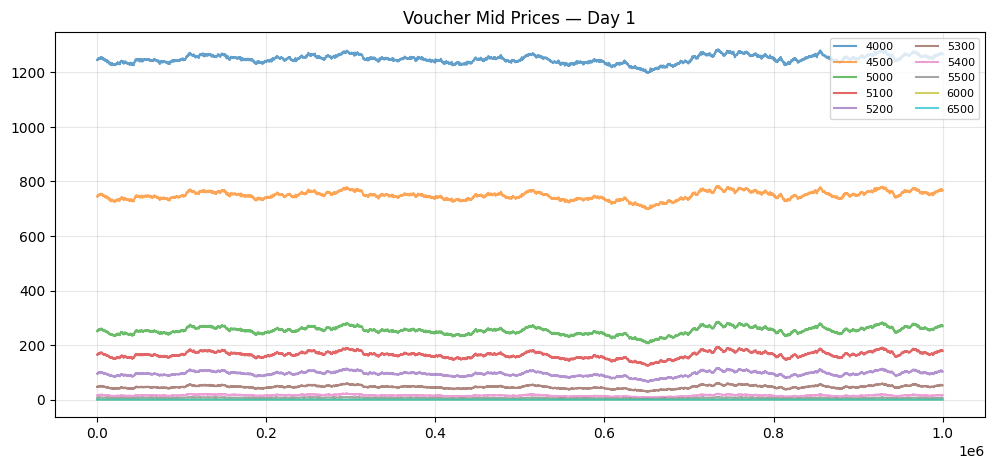

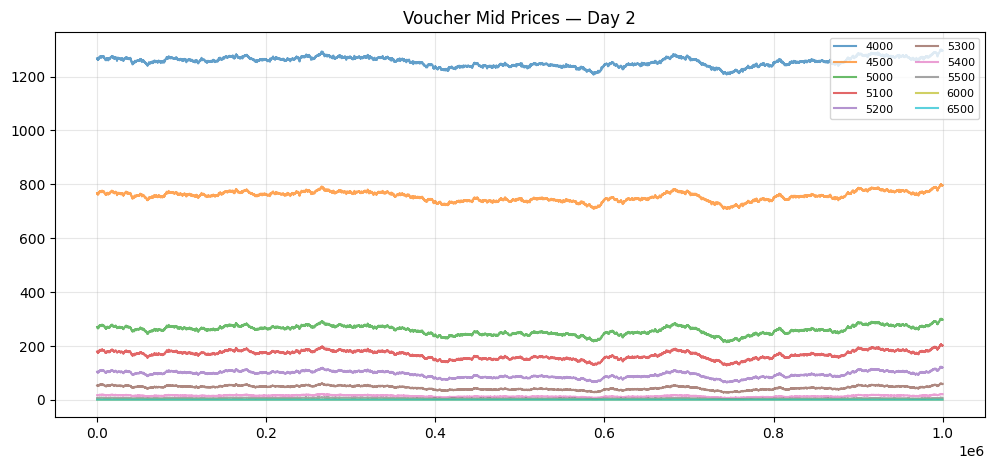

In [4]:
# =========================
# MID PRICE PLOTS
# =========================
for day, g in df.groupby("day"):
    plt.figure(figsize=(12,5))
    for strike, sub in g.groupby("strike"):
        plt.plot(sub["timestamp"], sub["option_mid"], label=str(strike), alpha=0.7)
    plt.title(f"Voucher Mid Prices — Day {day}")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()


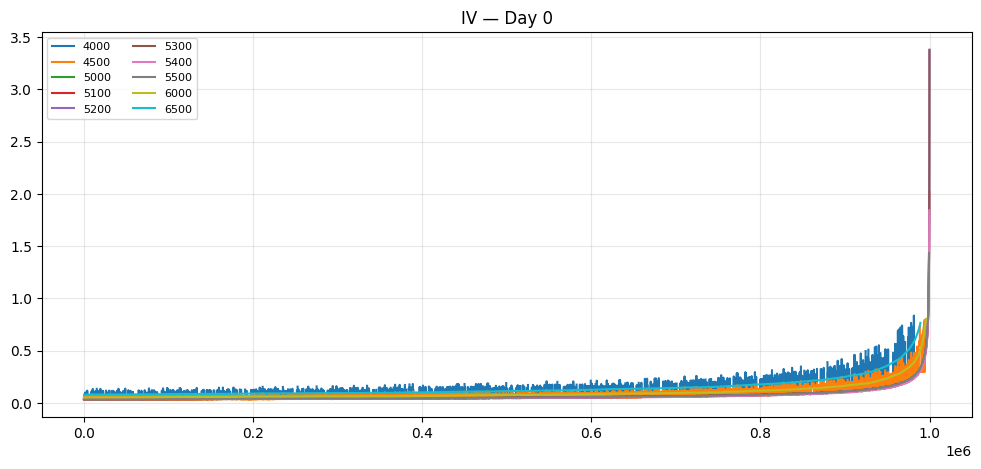

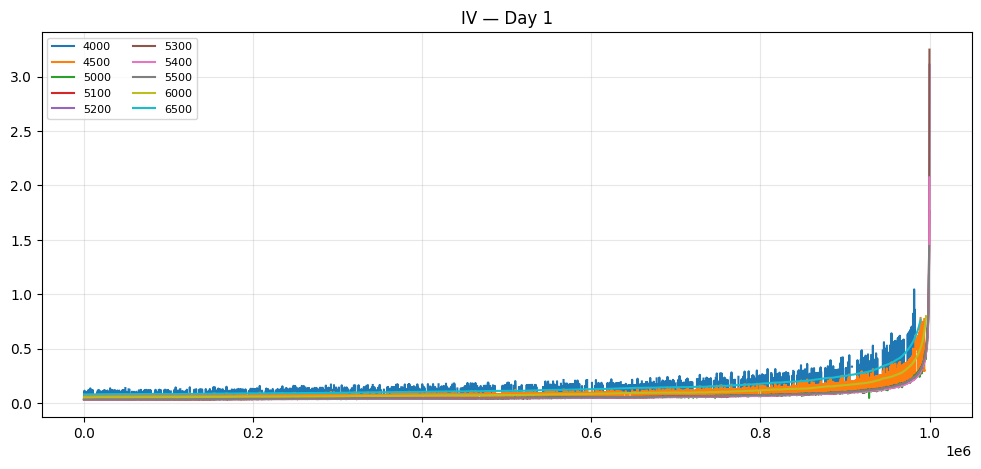

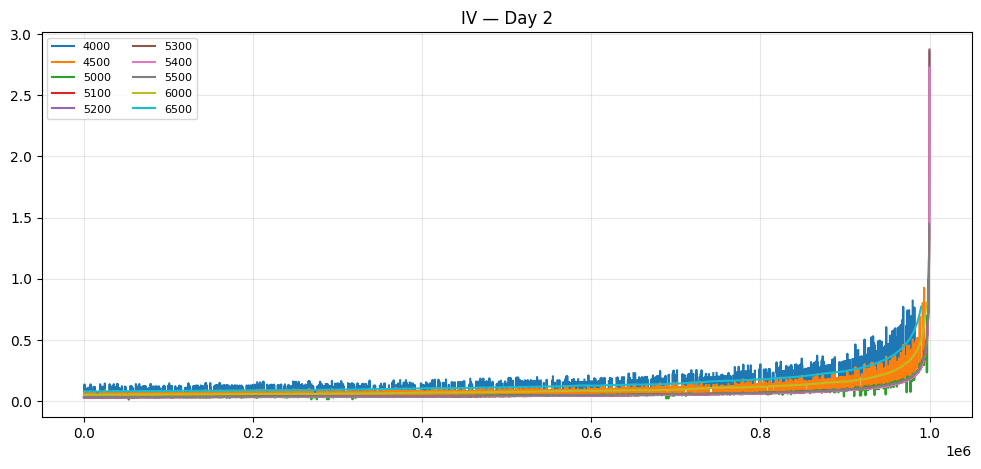

In [5]:
# =========================
# IV PLOTS
# =========================
for day, g in df.groupby("day"):
    plt.figure(figsize=(12,5))
    for strike, sub in g.groupby("strike"):
        plt.plot(sub["timestamp"], sub["iv"], label=str(strike))
    plt.title(f"IV — Day {day}")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

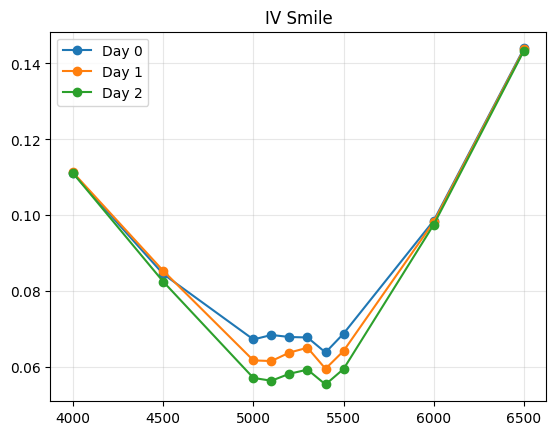

In [6]:
# =========================
# IV SMILE
# =========================
for day, g in df.groupby("day"):
    snap = g.groupby("strike")["iv"].mean()
    plt.plot(snap.index, snap.values, marker='o', label=f"Day {day}")

plt.title("IV Smile")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# =========================
# ATM IV (FIXED)
# =========================
df["dist"] = np.abs(df["strike"] - df["S"])
atm_idx = df.groupby(["day","timestamp"])["dist"].idxmin()

atm_df = df.loc[atm_idx, ["day","timestamp","iv"]].rename(columns={"iv":"atm_iv"})
df = df.merge(atm_df, on=["day","timestamp"], how="left")

df["iv_spread"] = df["iv"] - df["atm_iv"]


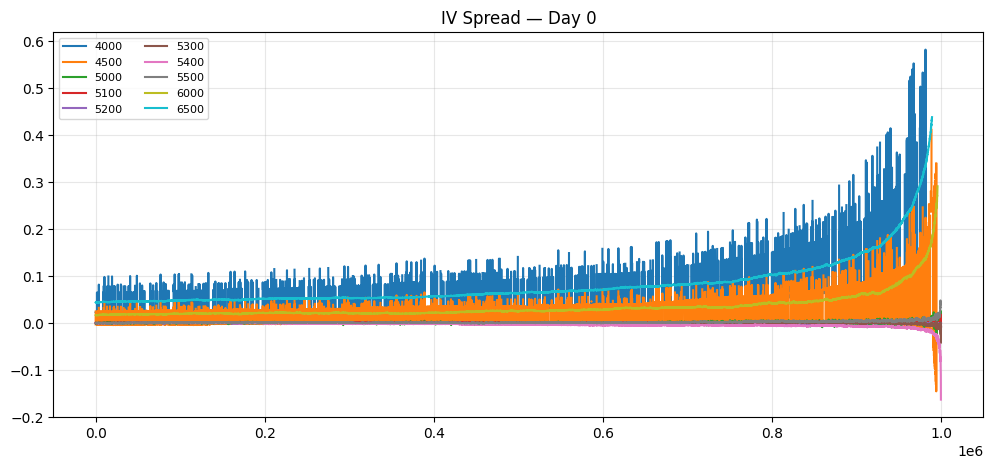

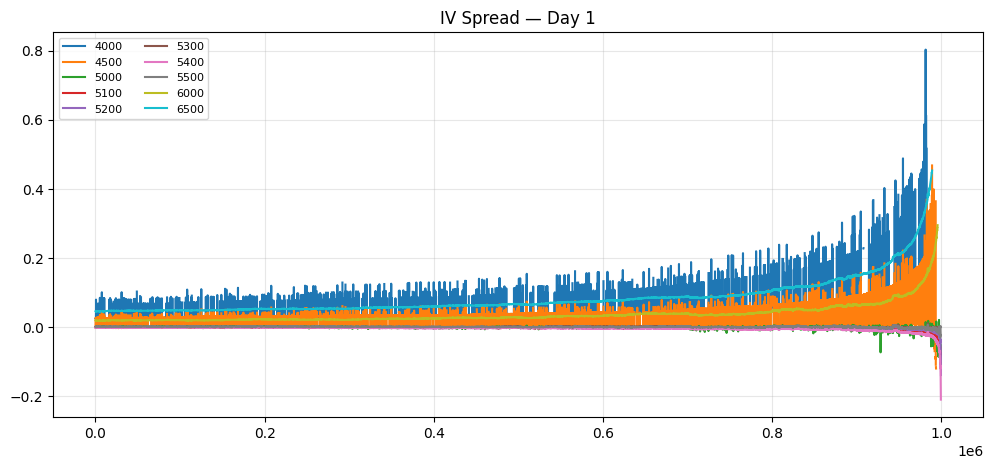

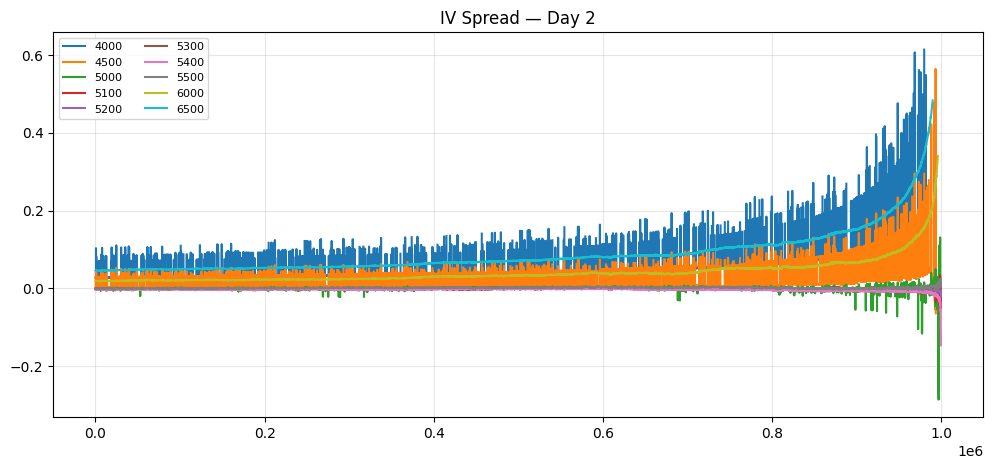

In [8]:
# =========================
# IV SPREAD
# =========================
for day, g in df.groupby("day"):
    plt.figure(figsize=(12,5))
    for strike, sub in g.groupby("strike"):
        plt.plot(sub["timestamp"], sub["iv_spread"], label=str(strike))
    plt.title(f"IV Spread — Day {day}")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
# =========================
# VECTORISED BS / DELTA / VEGA
# =========================
valid = df["atm_iv"] > 0

d1 = (np.log(df.loc[valid,"S"]/df.loc[valid,"strike"]) +
      0.5*df.loc[valid,"atm_iv"]**2 * df.loc[valid,"T"]) / (
      df.loc[valid,"atm_iv"] * np.sqrt(df.loc[valid,"T"])
)

d2 = d1 - df.loc[valid,"atm_iv"] * np.sqrt(df.loc[valid,"T"])

df.loc[valid, "bs_price"] = df.loc[valid,"S"] * norm.cdf(d1) - df.loc[valid,"strike"] * norm.cdf(d2)
df.loc[valid, "delta"] = norm.cdf(d1)
df.loc[valid, "vega"] = df.loc[valid,"S"] * norm.pdf(d1) * np.sqrt(df.loc[valid,"T"])


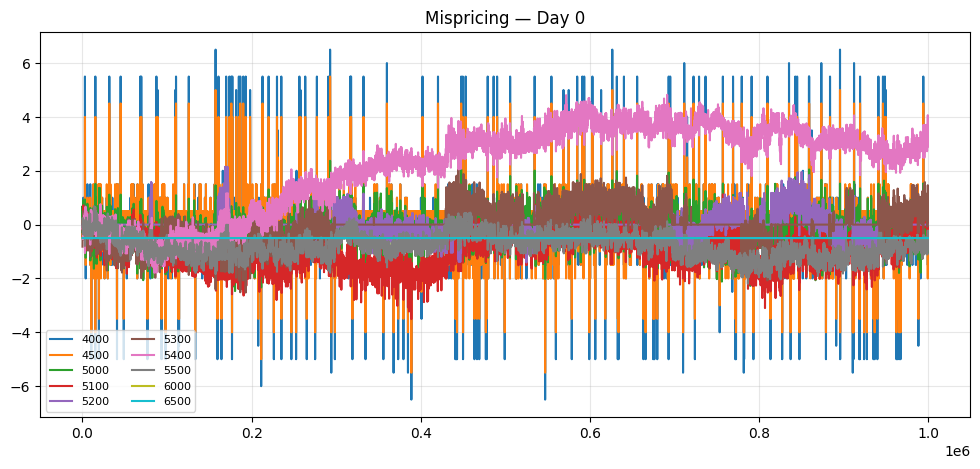

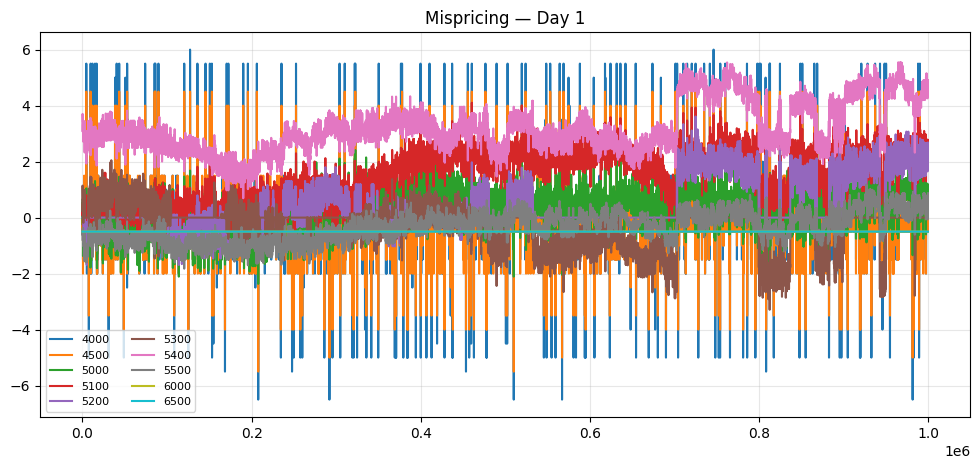

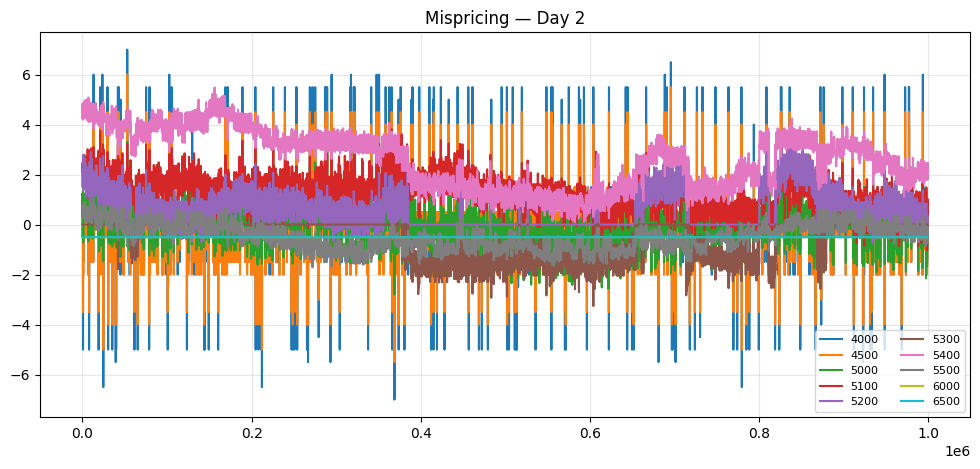

In [10]:
# =========================
# MISPRICING
# =========================
df["mispricing"] = df["bs_price"] - df["option_mid"]

for day, g in df.groupby("day"):
    plt.figure(figsize=(12,5))
    for strike, sub in g.groupby("strike"):
        plt.plot(sub["timestamp"], sub["mispricing"], label=str(strike))
    plt.title(f"Mispricing — Day {day}")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()


In [11]:
# Mean IV per timestamp (across strikes)
df["iv_mean"] = df.groupby(["day","timestamp"])["iv"].transform("mean")

# Deviation
df["iv_dev"] = df["iv"] - df["iv_mean"]

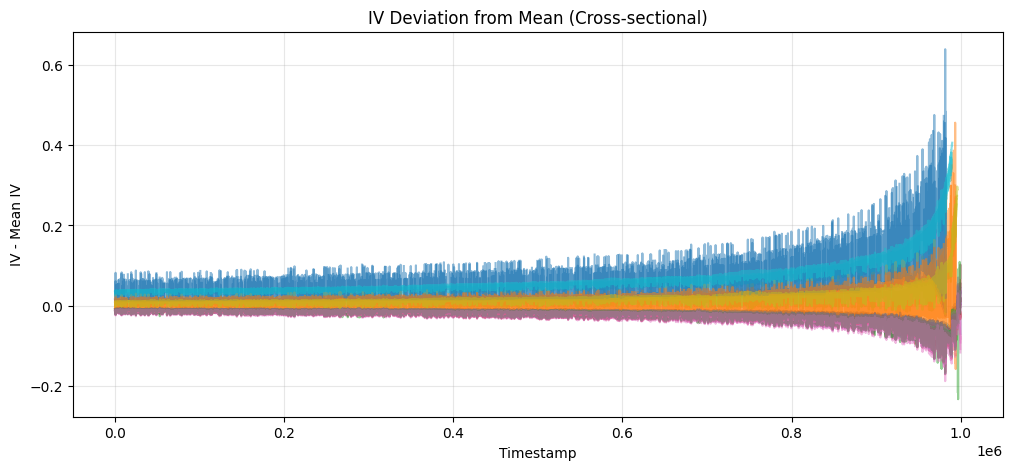

In [12]:
plt.figure(figsize=(12,5))

for day, g in df.groupby("day"):
    for strike, sub in g.groupby("strike"):
        plt.plot(sub["timestamp"], sub["iv_dev"], alpha=0.5, label=f"{strike}" if day==0 else None)

plt.title("IV Deviation from Mean (Cross-sectional)")
plt.xlabel("Timestamp")
plt.ylabel("IV - Mean IV")
plt.grid(alpha=0.3)
plt.show()

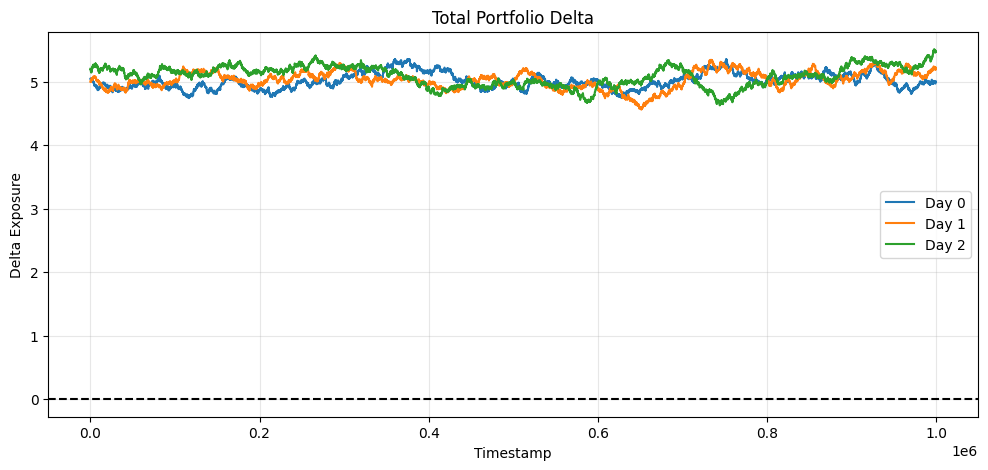

In [13]:
# If no positions, assume 1 each
df["position"] = 1

# Portfolio delta
df["position_delta"] = df["delta"] * df["position"]

portfolio_delta = df.groupby(["day","timestamp"])["position_delta"].sum().reset_index()


plt.figure(figsize=(12,5))

for day, g in portfolio_delta.groupby("day"):
    plt.plot(g["timestamp"], g["position_delta"], label=f"Day {day}")

plt.axhline(0, color='black', linestyle='--')

plt.title("Total Portfolio Delta")
plt.xlabel("Timestamp")
plt.ylabel("Delta Exposure")
plt.legend()
plt.grid(alpha=0.3)
plt.show()